# StockSense Round 2 — Feature Engineering & Machine Learning
**Person 2: ML Engineer**

This notebook documents the complete Round 2 ML pipeline:
1. Dataset inspection
2. Feature engineering
3. Target creation
4. Leakage audit
5. Temporal train/val/test split
6. Demand baseline + model comparison
7. Stock-out classification
8. Feature importance
9. Error analysis
10. Final conclusions


## 1. Imports & Setup

In [1]:
import os, sys, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Add src to path so we can import the project modules
sys.path.insert(0, os.path.join('..', 'src'))
print('Setup complete.')


Setup complete.


## 2. Load & Inspect Master Dataset

In [2]:
master = pd.read_csv('../data/processed/master_daily.csv')
master['date'] = pd.to_datetime(master['date'])
print('Shape:', master.shape)
print('Columns:', list(master.columns))


Shape: (6440, 34)
Columns: ['date', 'opening', 'received', 'sold', 'closing', 'reorder_lvl', 'lead_days', 'store_id', 'product_id', 'units_sold', 'revenue', 'average_selling_price', 'average_discount_pct', 'promotion_flag', 'transaction_count', 'unique_customer_count', 'category', 'sub_category', 'brand', 'mrp', 'cost_price', 'shelf_life_days', 'supplier_id', 'city', 'store_type', 'floor_area_sqft', 'avg_daily_customers', 'region', 'temp_c', 'rain_mm', 'holiday', 'festival', 'weekend', 'local_event']


In [3]:
print('Date range:', master['date'].min().date(), 'to', master['date'].max().date())
print('Stores:', sorted(master['store_id'].unique()))
print('Products:', sorted(master['product_id'].unique()))
print('Missing values:', master.isnull().sum().sum())
print('Duplicate Date-Store-Product keys:', 
      master.duplicated(['date','store_id','product_id']).sum())


Date range: 2026-05-01 to 2026-08-31
Stores: ['S01', 'S02', 'S03', 'S04']
Products: ['P101', 'P102', 'P201', 'P205', 'P330', 'P331', 'P442', 'P443', 'P501', 'P502', 'P601', 'P701', 'P702', 'P999']
Missing values: 0
Duplicate Date-Store-Product keys: 0


In [4]:
print('=== Numerical summary ===')
master.describe().round(2)


=== Numerical summary ===


,date,opening,received,sold,closing,reorder_lvl,lead_days,units_sold,revenue,average_selling_price,...,cost_price,shelf_life_days,floor_area_sqft,avg_daily_customers,temp_c,rain_mm,holiday,festival,weekend,local_event
count,6440,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00,...,6440.00,6440.00,6440.0,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00
mean,2026-07-01 09:10:57.391304192,256.59,53.85,52.67,257.77,136.15,2.51,52.67,4403.49,130.56,...,99.52,302.47,9575.0,1475.00,31.91,2.20,0.02,0.02,0.29,0.05
min,2026-05-01 00:00:00,6.00,0.00,2.00,6.00,21.00,1.00,2.00,160.00,17.35,...,12.00,3.00,4200.0,720.00,21.60,0.00,0.00,0.00,0.00,0.00
25%,2026-05-31 00:00:00,90.00,0.00,20.00,90.00,54.00,2.00,20.00,1881.00,50.00,...,31.00,120.00,6750.0,990.00,30.00,0.00,0.00,0.00,0.00,0.00
50%,2026-07-01 00:00:00,163.00,0.00,36.00,164.50,93.00,3.00,36.00,3000.00,90.00,...,60.00,180.00,8050.0,1165.00,31.90,0.70,0.00,0.00,0.00,0.00
75%,2026-08-01 00:00:00,313.00,0.00,66.00,315.00,171.00,4.00,66.00,5705.00,120.00,...,95.00,365.00,10875.0,1650.00,33.70,3.80,0.00,0.00,1.00,0.00
max,2026-08-31 00:00:00,2083.00,2146.00,624.00,2083.00,684.00,4.00,624.00,38500.00,600.00,...,500.00,730.00,18000.0,2850.00,40.30,19.30,1.00,1.00,1.00,1.00
std,NaN,275.25,180.99,52.33,276.31,127.04,1.12,52.33,4089.89,145.01,...,122.79,254.66,5122.1,816.66,2.98,2.99,0.13,0.13,0.46,0.22


In [5]:
print('=== Categorical columns ===')
for col in ['category','sub_category','brand','store_type','region','city']:
    print(f'  {col}: {sorted(master[col].unique())}')


=== Categorical columns ===
  category: ['Beverages', 'Dairy', 'Frozen', 'Groceries', 'Household', 'Personal Care', 'Snacks']
  sub_category: ['Biscuits', 'Cheese', 'Chips', 'Cleaner', 'Dal', 'Energy Drink', 'Ice Cream', 'Juice', 'Milk', 'Peas', 'Rice', 'Shampoo', 'Soap', 'Soft Drink']
  brand: ['Aavin', 'ChillZ', 'Crispo', 'Crunchy', 'FarmGold', 'FizzUp', 'GlowCare', 'IceFarm', 'MilkyWay', 'NatureFresh', 'Shine', 'Zap']
  store_type: ['Express', 'Hypermarket', 'Supermarket']
  region: ['Central', 'North', 'South', 'West']
  city: ['Chennai', 'Coimbatore', 'Madurai', 'Salem']


In [6]:
print('=== Inventory columns ===')
master[['opening','received','sold','closing','reorder_lvl','lead_days']].describe().round(2)


=== Inventory columns ===


,opening,received,sold,closing,reorder_lvl,lead_days
count,6440.00,6440.00,6440.00,6440.00,6440.00,6440.00
mean,256.59,53.85,52.67,257.77,136.15,2.51
std,275.25,180.99,52.33,276.31,127.04,1.12
min,6.00,0.00,2.00,6.00,21.00,1.00
25%,90.00,0.00,20.00,90.00,54.00,2.00
50%,163.00,0.00,36.00,164.50,93.00,3.00
75%,313.00,0.00,66.00,315.00,171.00,4.00
max,2083.00,2146.00,624.00,2083.00,684.00,4.00


## 3. Feature Engineering
Run the feature engineering module to build all features and targets.

In [7]:
from feature_engineering import build_features
df = build_features(save=True)
print('Feature matrix shape:', df.shape)
print('New columns added:', [c for c in df.columns if c not in master.columns])


[INFO] Loaded master_daily.csv  shape=(6440, 34)
[INFO] Time features added.
[INFO] Lag and rolling features added.
[INFO] Inventory features added.
       stockout_flag positive=931 (14.5%)
[INFO] Price/Promotion features added.
[INFO] Store/Product features added.
[INFO] next_7_day_demand created.
       Usable rows (complete window): 6048 / 6440
       Excluded (incomplete window):  392

[INFO] Final feature matrix shape: (6440, 68)
[INFO] Saved: c:\Users\harsh\Desktop\STOCKSENSE_THE_ALGONAUTS\STOCKSENSE\data\processed\ml_features.csv
[INFO] Leakage report saved: c:\Users\harsh\Desktop\STOCKSENSE_THE_ALGONAUTS\STOCKSENSE\reports\ml_leakage_check.md
Feature matrix shape: (6440, 68)
New columns added: ['day_of_week', 'weekend_flag', 'month', 'week_no', 'day_of_month', 'quarter', 'festival_flag', 'holiday_or_festival', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'lag_closing_1', 'lag_closing_7', 'days_of_inventory', 'inventory_to_demand_ratio', 're

### 3.1 Time Features

In [8]:
time_cols = ['day_of_week','weekend_flag','month','week_no','festival_flag','holiday_or_festival']
print(df[time_cols].describe().round(2))


       day_of_week  weekend_flag    month  week_no  festival_flag  \
count      6440.00       6440.00  6440.00  6440.00        6440.00   
mean          3.03          0.29     6.51    26.91           0.07   
std           2.02          0.46     1.12     5.11           0.25   
min           0.00          0.00     5.00    18.00           0.00   
25%           1.00          0.00     5.00    22.00           0.00   
50%           3.00          0.00     7.00    27.00           0.00   
75%           5.00          1.00     8.00    31.00           0.00   
max           6.00          1.00     8.00    36.00           1.00   

       holiday_or_festival  
count              6440.00  
mean                  0.07  
std                   0.25  
min                   0.00  
25%                   0.00  
50%                   0.00  
75%                   0.00  
max                   1.00  


### 3.2 Lag & Rolling Features
All computed **within each (store_id, product_id) group**, sorted by date.
No future information is used.

In [9]:
lag_cols = ['lag_1','lag_7','lag_14','rolling_mean_7','rolling_mean_14','rolling_std_7']
print(df[lag_cols].describe().round(2))

# Example: one store-product pair
sample = df[(df['store_id']=='S01') & (df['product_id']=='P101')].head(20)
sample[['date','units_sold','lag_1','lag_7','rolling_mean_7']]


         lag_1    lag_7   lag_14  rolling_mean_7  rolling_mean_14  \
count  6440.00  6440.00  6440.00         6384.00          6384.00   
mean     52.66    51.96    51.93           52.48            52.23   
std      52.27    50.89    50.80           49.55            49.08   
min       2.00     2.00     2.00            5.86             6.86   
25%      20.00    20.00    20.00           20.00            20.14   
50%      36.00    35.00    35.00           35.29            35.14   
75%      66.00    65.00    65.00           66.46            66.02   
max     624.00   482.00   482.00          344.00           309.86   

       rolling_std_7  
count        6440.00  
mean           11.88  
std            12.18  
min             0.00  
25%             5.05  
50%             8.32  
75%            13.84  
max           147.31  


,date,units_sold,lag_1,lag_7,rolling_mean_7
0,2026-05-01,61,61.0,61.000000,NaN
1,2026-05-02,66,61.0,61.000000,61.000000
2,2026-05-03,93,66.0,63.500000,63.500000
3,2026-05-04,54,93.0,73.333333,73.333333
4,2026-05-05,64,54.0,68.500000,68.500000
5,2026-05-06,63,64.0,67.600000,67.600000
6,2026-05-07,66,63.0,66.833333,66.833333
7,2026-05-08,76,66.0,61.000000,66.714286
8,2026-05-09,81,76.0,66.000000,68.857143
9,2026-05-10,84,81.0,93.000000,71.000000


## 4. Target Creation
### 4.1 Demand Target: `next_7_day_demand`
**Definition**: Sum of `units_sold` for days t+1 through t+7 per (store_id, product_id).
Rows with incomplete 7-day future window → NaN → excluded from training.

In [10]:
print('next_7_day_demand stats:')
print(df['next_7_day_demand'].describe().round(2))
print('NaN rows (excluded):', df['next_7_day_demand'].isna().sum())
print('Usable rows:', df['next_7_day_demand'].notna().sum())


next_7_day_demand stats:
count    6048.00
mean      368.87
std       349.15
min        41.00
25%       141.00
50%       248.00
75%       467.25
max      2408.00
Name: next_7_day_demand, dtype: float64
NaN rows (excluded): 392
Usable rows: 6048


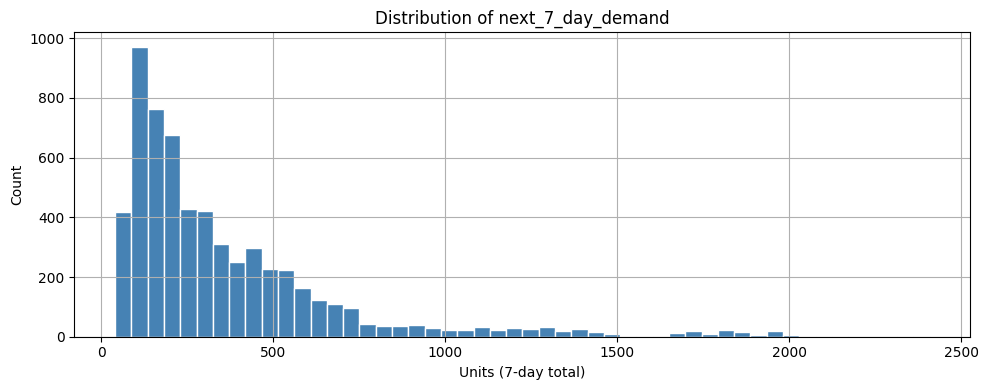

In [11]:
# Distribution of next_7_day_demand
fig, ax = plt.subplots(figsize=(10, 4))
df['next_7_day_demand'].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of next_7_day_demand')
ax.set_xlabel('Units (7-day total)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


### 4.2 Stock-out Target: `stockout_flag`
**Definition**: `1` if `closing < reorder_lvl`, else `0`.
**Rationale**: Below the reorder threshold → imminent stock-out risk.

In [12]:
print('stockout_flag distribution:')
vc = df['stockout_flag'].value_counts()
print(vc)
print(f'Positive rate: {vc[1]/len(df)*100:.1f}%')


stockout_flag distribution:
stockout_flag
0    5509
1     931
Name: count, dtype: int64
Positive rate: 14.5%


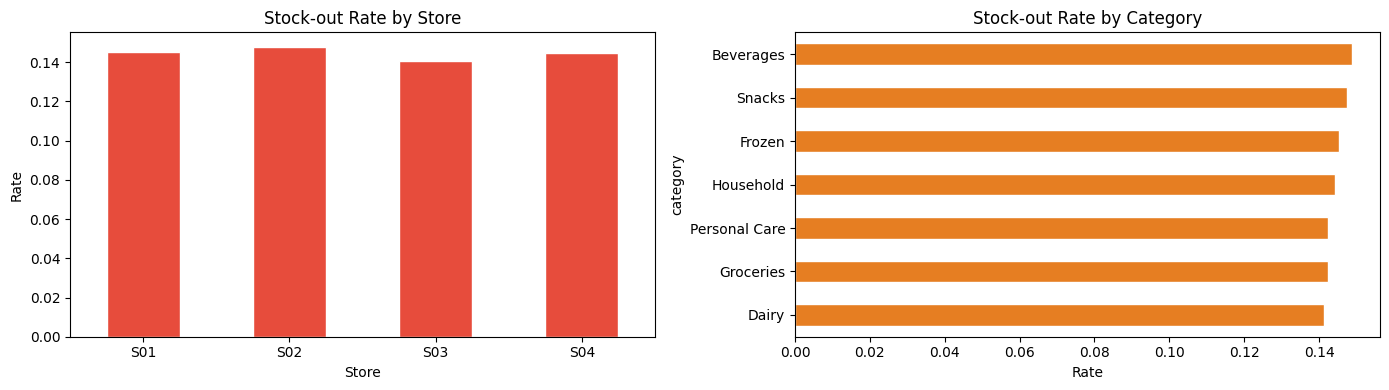

In [13]:
# Stock-out by store and category
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('store_id')['stockout_flag'].mean().plot(kind='bar', ax=axes[0], 
    color='#e74c3c', edgecolor='white')
axes[0].set_title('Stock-out Rate by Store')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Rate')
axes[0].tick_params(rotation=0)

df.groupby('category')['stockout_flag'].mean().sort_values().plot(kind='barh', ax=axes[1],
    color='#e67e22', edgecolor='white')
axes[1].set_title('Stock-out Rate by Category')
axes[1].set_xlabel('Rate')

plt.tight_layout()
plt.show()


## 5. Data Leakage Audit
Full audit in `reports/ml_leakage_check.md`.

**Key guarantees**:
- Lag features use `.shift(n)` with n≥1 within each (store_id, product_id) group.
- Rolling features use `.shift(1).rolling(n)` — current day excluded.
- `next_7_day_demand` is only the target, never a predictor.
- Inventory features `reorder_gap`, `days_of_inventory`, `stock_coverage_ratio`
  are **excluded from the stockout model** because they algebraically encode the target.


In [14]:
# Print leakage report summary
with open('../reports/ml_leakage_check.md', 'r') as f:
    content = f.read()
# Show first 2000 chars
print(content[:2000])


# Data Leakage Audit â€” StockSense Round 2

## Overview
At prediction time *t*, only information from days t and earlier is available.
This document confirms that every feature respects that constraint.

---

## Feature-by-Feature Audit

### A. Time Features â€” NO LEAKAGE
| Feature | Source | Risk |
|---|---|---|
| `day_of_week` | `date` (calendar math) | None |
| `weekend_flag` | `date` | None |
| `month` | `date` | None |
| `week_no` | `date` | None |
| `day_of_month` | `date` | None |
| `quarter` | `date` | None |
| `festival_flag` | `festival` col + fixed calendar | None â€” known in advance |
| `holiday` | existing column | None |
| `local_event` | existing column | None |
| `holiday_or_festival` | derived from above | None |

### B. Lag Features â€” NO LEAKAGE
All lag features use `.shift(n)` within each (store_id, product_id) group sorted by date.
shift(n) for n>=1 accesses only historical rows.

| Feature | Lag | Risk |
|---|---|---|
| `lag_1`  | units_sold at t-1 | None |
| 

## 6. Time-Aware Train / Validation / Test Split
**No random shuffling.** Split by calendar date only.

| Split | Dates | Rows (demand) |
|---|---|---|
| Train | 2026-05-01 to 2026-07-25 | ~4,472 |
| Validation | 2026-07-26 to 2026-08-12 | ~936 |
| Test | 2026-08-13 to 2026-08-24 | ~640 |


In [15]:
TRAIN_END = '2026-07-25'
VAL_END   = '2026-08-12'

df_model = df.dropna(subset=['next_7_day_demand']).copy()
train = df_model[df_model['date'] <= TRAIN_END]
val   = df_model[(df_model['date'] > TRAIN_END) & (df_model['date'] <= VAL_END)]
test  = df_model[df_model['date'] > VAL_END]

print(f'Train: {len(train)} rows  ({train["date"].min().date()} to {train["date"].max().date()})')
print(f'Val:   {len(val)} rows  ({val["date"].min().date()} to {val["date"].max().date()})')
print(f'Test:  {len(test)} rows  ({test["date"].min().date()} to {test["date"].max().date()})')


Train: 4472 rows  (2026-05-01 to 2026-07-25)
Val:   936 rows  (2026-07-26 to 2026-08-12)
Test:  640 rows  (2026-08-13 to 2026-08-24)


## 7. Demand Baseline
**Strategy**: `predicted = rolling_mean_7 × 7`
The naive forecast is the previous 7-day mean scaled to the 7-day window.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape(y_true, y_pred):
    mask = y_true > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

y_true_val = val['next_7_day_demand'].values
y_pred_baseline_val = (val['rolling_mean_7'].fillna(0).values * 7)

print('=== Baseline (Validation) ===')
print(f'MAE:  {mean_absolute_error(y_true_val, y_pred_baseline_val):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_true_val, y_pred_baseline_val)):.3f}')
print(f'MAPE: {mape(y_true_val, y_pred_baseline_val):.2f}%')
print(f'R2:   {r2_score(y_true_val, y_pred_baseline_val):.4f}')


=== Baseline (Validation) ===
MAE:  30.708
RMSE: 46.427
MAPE: 9.95%
R2:   0.9812


## 8. Demand Model Comparison
Models: Linear Regression, Random Forest, XGBoost
Selection metric: **lowest Validation MAE**

In [17]:
comp = pd.read_csv('../reports/demand_model_comparison.csv')
comp


,model,split,MAE,RMSE,MAPE,R2
0,Baseline (rolling_mean_7 x7),Test,55.4995,89.6796,13.6870,0.9477
1,LinearRegression,Validation,29.0448,45.6501,9.7740,0.9818
2,RandomForest,Validation,26.0320,42.7945,8.2580,0.9840
3,XGBoost,Validation,26.1340,39.9134,8.2881,0.9861
4,LinearRegression,Test,79.9338,135.5238,26.4614,0.8799
5,RandomForest,Test,51.8688,89.8411,12.4817,0.9472
6,XGBoost,Test,51.9219,90.2022,12.6799,0.9468


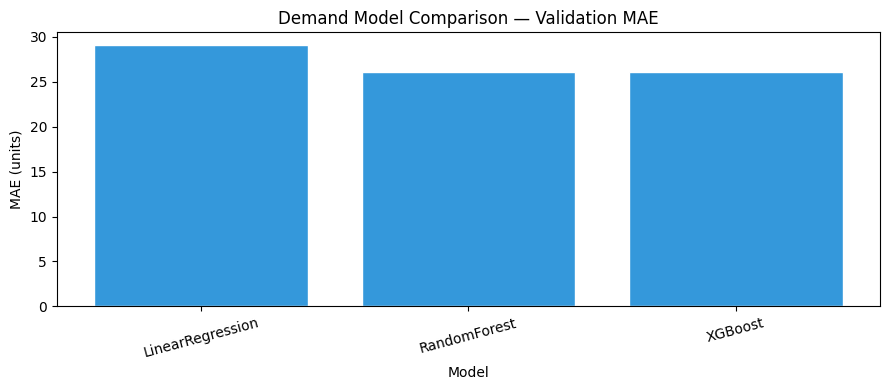

In [18]:
# Bar chart: Validation MAE comparison
val_rows = comp[comp['split']=='Validation'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#95a5a6' if 'Baseline' in m else '#3498db' for m in val_rows['model']]
ax.bar(val_rows['model'], val_rows['MAE'], color=colors, edgecolor='white')
ax.set_title('Demand Model Comparison — Validation MAE')
ax.set_ylabel('MAE (units)')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 9. Selected Demand Model: Random Forest
Selected because it has the **lowest Validation MAE** (26.03 vs 26.13 for XGBoost).
Both RF and XGBoost are essentially tied; RF is chosen by the MAE criterion.

In [19]:
# Load the saved model
with open('../models/demand_model.pkl', 'rb') as f:
    demand_model = pickle.load(f)
with open('../models/demand_scaler.pkl', 'rb') as f:
    demand_scaler = pickle.load(f)

print('Loaded model:', type(demand_model).__name__)


Loaded model: RandomForestRegressor


## 10. Demand Test Set Evaluation

In [20]:
demand_preds = pd.read_csv('../data/processed/demand_predictions.csv')
demand_preds['date'] = pd.to_datetime(demand_preds['date'])

y_true_te = demand_preds['actual_next_7_day_demand'].values
y_pred_te = demand_preds['predicted_next_7_day_demand'].values

print('=== Random Forest (Test) ===')
print(f'MAE:  {mean_absolute_error(y_true_te, y_pred_te):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_true_te, y_pred_te)):.3f}')
print(f'MAPE: {mape(y_true_te, y_pred_te):.2f}%')
print(f'R2:   {r2_score(y_true_te, y_pred_te):.4f}')


=== Random Forest (Test) ===
MAE:  51.869
RMSE: 89.841
MAPE: 12.48%
R2:   0.9472


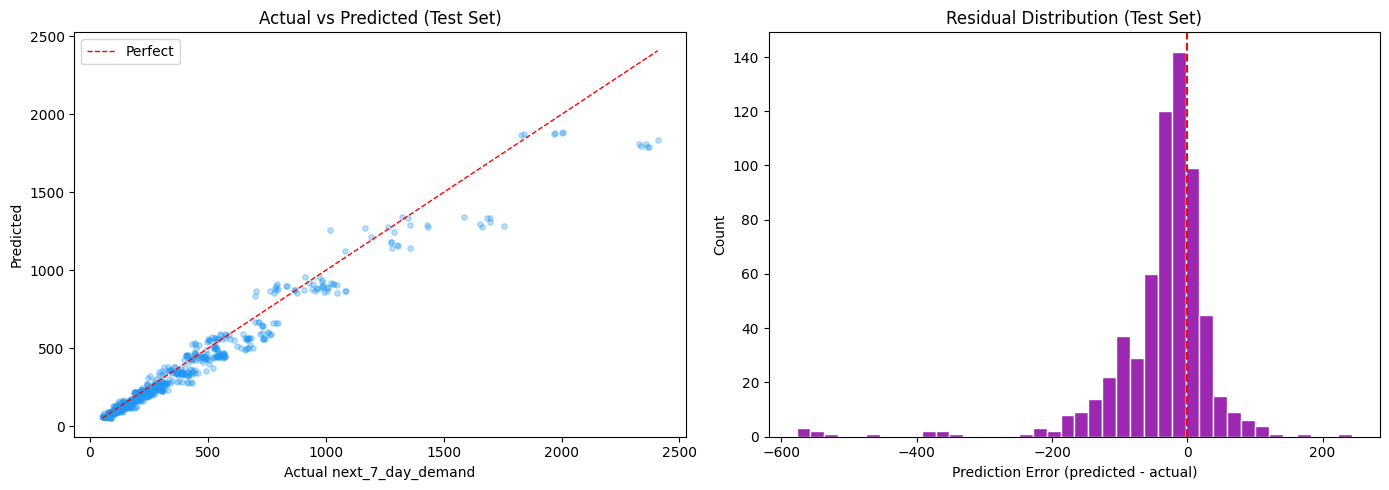

In [21]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true_te, y_pred_te, alpha=0.3, s=15, color='#2196F3')
lims = [min(y_true_te.min(), y_pred_te.min()), max(y_true_te.max(), y_pred_te.max())]
axes[0].plot(lims, lims, 'r--', lw=1, label='Perfect')
axes[0].set_xlabel('Actual next_7_day_demand')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

errors = y_pred_te - y_true_te
axes[1].hist(errors, bins=40, color='#9C27B0', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error (predicted - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (Test Set)')

plt.tight_layout()
plt.show()


## 11. Stock-out Target Analysis

In [22]:
print('stockout_flag = 1 when closing < reorder_lvl')
print()
print('Overall distribution:')
print(df['stockout_flag'].value_counts())
print(f'Positive rate: {df["stockout_flag"].mean()*100:.1f}%')


stockout_flag = 1 when closing < reorder_lvl

Overall distribution:
stockout_flag
0    5509
1     931
Name: count, dtype: int64
Positive rate: 14.5%


## 12. Class Imbalance Analysis

In [23]:
# Class imbalance by split
for name, split in [('Train', df[df['date'] <= TRAIN_END]),
                     ('Val',   df[(df['date'] > TRAIN_END) & (df['date'] <= VAL_END)]),
                     ('Test',  df[df['date'] > VAL_END])]:
    pos = split['stockout_flag'].sum()
    pct = pos/len(split)*100
    print(f'{name}: {pos} positives out of {len(split)} ({pct:.1f}%)')

print()
print('Class imbalance handled by: class_weight=balanced (sklearn) + scale_pos_weight (XGBoost)')


Train: 631 positives out of 4472 (14.1%)
Val: 138 positives out of 936 (14.7%)
Test: 162 positives out of 1032 (15.7%)

Class imbalance handled by: class_weight=balanced (sklearn) + scale_pos_weight (XGBoost)


## 13. Stock-out Model Comparison
Models: Logistic Regression, Decision Tree, Random Forest, XGBoost
Selection metric: **highest Validation F1** (with Recall as tiebreaker)

In [24]:
scomp = pd.read_csv('../reports/stockout_model_comparison.csv')
scomp


,model,split,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,Validation,0.8077,0.4318,0.9638,0.5964,0.9298
1,LogisticRegression,Test,0.7248,0.3555,0.9259,0.5137,0.8617
2,DecisionTree,Validation,0.8280,0.4569,0.8841,0.6025,0.8766
3,DecisionTree,Test,0.7713,0.3879,0.7901,0.5203,0.8150
4,RandomForest,Validation,0.8889,0.6250,0.6159,0.6204,0.9420
5,RandomForest,Test,0.8798,0.6532,0.5000,0.5664,0.9047
6,XGBoost,Validation,0.9391,0.7485,0.8841,0.8106,0.9789
7,XGBoost,Test,0.9012,0.6705,0.7284,0.6982,0.9503


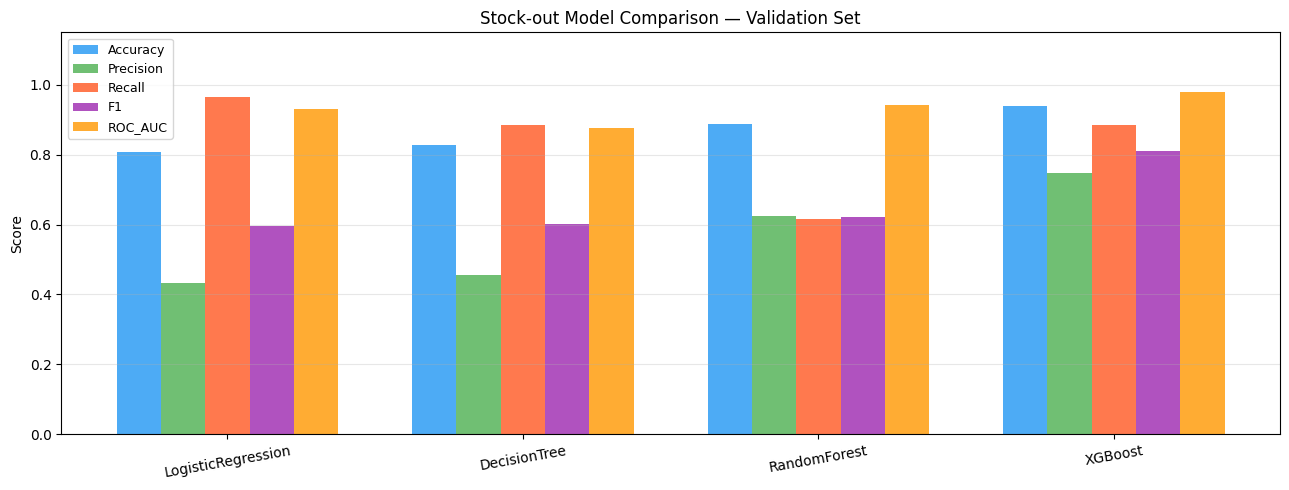

In [25]:
# Validation metrics bar chart
val_sc = scomp[scomp['split']=='Validation'].copy()
metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x = np.arange(len(val_sc))
width = 0.15
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800']
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, val_sc[metric], width, label=metric, color=color, alpha=0.8)
ax.set_xticks(x + width*2)
ax.set_xticklabels(val_sc['model'], rotation=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Stock-out Model Comparison — Validation Set')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Selected Classifier: XGBoost
- Highest Validation F1 = 0.8106
- Recall = 0.8841 (capturing most stock-out cases)
- AUC = 0.9789 (excellent discrimination)

In [26]:
with open('../models/stockout_model.pkl', 'rb') as f:
    stockout_model = pickle.load(f)
print('Loaded classifier:', type(stockout_model).__name__)


Loaded classifier: XGBClassifier


## 15. Stockout Test Evaluation

In [27]:
spred = pd.read_csv('../data/processed/stockout_predictions.csv')

y_true_s = spred['actual_stockout_flag'].values
y_pred_s = spred['stockout_prediction'].values
y_prob_s = spred['stockout_probability'].values

print('=== XGBoost Classifier (Test) ===')
print(f'Accuracy:  {accuracy_score(y_true_s, y_pred_s):.4f}')
print(f'Precision: {precision_score(y_true_s, y_pred_s):.4f}')
print(f'Recall:    {recall_score(y_true_s, y_pred_s):.4f}')
print(f'F1:        {f1_score(y_true_s, y_pred_s):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_true_s, y_prob_s):.4f}')


=== XGBoost Classifier (Test) ===
Accuracy:  0.9012
Precision: 0.6705
Recall:    0.7284
F1:        0.6982
ROC-AUC:   0.9503


## 16. Confusion Matrix

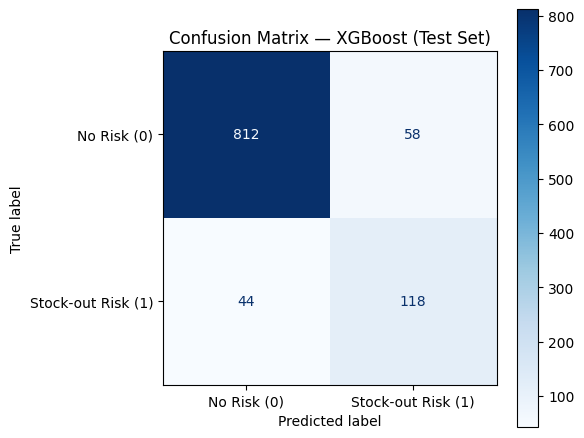

TN=812  FP=58  FN=44  TP=118
Missed stock-outs (FN): 44
False alarms (FP): 58


In [28]:
cm = confusion_matrix(y_true_s, y_pred_s)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Risk (0)', 'Stock-out Risk (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost (Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Missed stock-outs (FN): {fn}')
print(f'False alarms (FP): {fp}')


## 17. Feature Importance

In [29]:
# Demand model feature importance
demand_fi = pd.read_csv('../reports/demand_feature_importance.csv')
print('Top 15 features — Demand (RandomForest):')
print(demand_fi.head(15).to_string(index=False))


Top 15 features — Demand (RandomForest):
          feature  importance
  rolling_mean_14    0.887041
   rolling_mean_7    0.059679
           lag_14    0.013717
      reorder_gap    0.006351
        brand_enc    0.005126
            lag_7    0.004849
mrp_to_cost_ratio    0.003553
            lag_1    0.002669
   product_id_enc    0.002540
       cost_price    0.002369
          week_no    0.002369
  shelf_life_days    0.002171
              mrp    0.001699
    rolling_std_7    0.001304
     day_of_month    0.001266


In [30]:
# Stockout model feature importance
stockout_fi = pd.read_csv('../reports/stockout_feature_importance.csv')
print('Top 15 features — Stockout (XGBoost):')
print(stockout_fi.head(15).to_string(index=False))


Top 15 features — Stockout (XGBoost):
            feature  importance
      lag_closing_1    0.089168
        reorder_lvl    0.083712
     rolling_mean_7    0.067950
      lag_closing_7    0.066622
    rolling_mean_14    0.066209
     promotion_flag    0.043644
              lag_7    0.040594
             lag_14    0.033944
              lag_1    0.032135
       discount_pct    0.025213
            week_no    0.023837
       price_change    0.022705
holiday_or_festival    0.022364
        day_of_week    0.019633
      festival_flag    0.019380


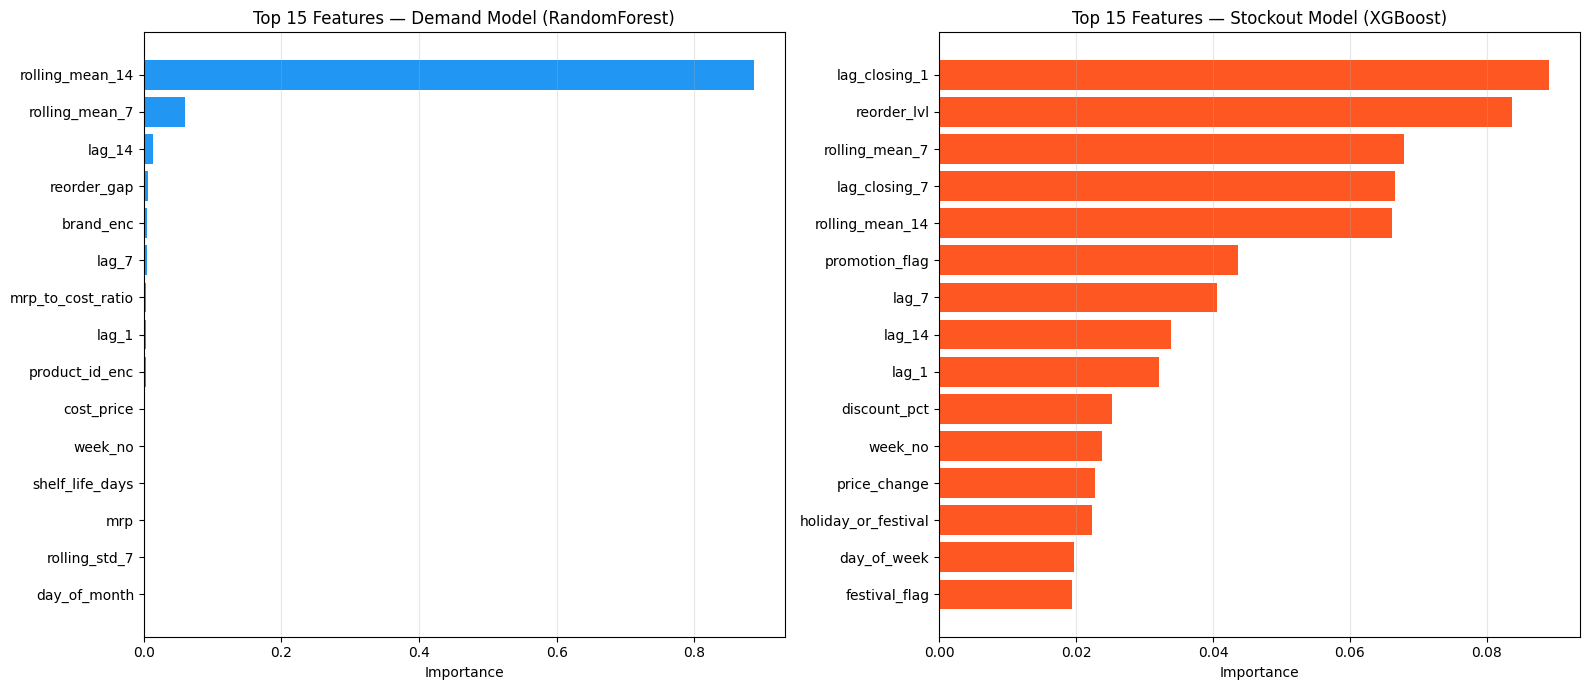

In [31]:
# Side-by-side importance charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_d = demand_fi.head(15)
axes[0].barh(top_d['feature'][::-1], top_d['importance'][::-1], color='#2196F3')
axes[0].set_title('Top 15 Features — Demand Model (RandomForest)')
axes[0].set_xlabel('Importance')
axes[0].grid(axis='x', alpha=0.3)

top_s = stockout_fi.head(15)
axes[1].barh(top_s['feature'][::-1], top_s['importance'][::-1], color='#FF5722')
axes[1].set_title('Top 15 Features — Stockout Model (XGBoost)')
axes[1].set_xlabel('Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## 18. Error Analysis

In [32]:
# Demand errors
demand_preds['error'] = demand_preds['actual_next_7_day_demand'] - demand_preds['predicted_next_7_day_demand']
demand_preds['abs_error'] = demand_preds['error'].abs()

print('=== High-error products ===')
print(demand_preds.groupby('product_id')['abs_error'].mean().sort_values(ascending=False).head(5))

print()
print('=== High-error stores ===')
print(demand_preds.groupby('store_id')['abs_error'].mean().sort_values(ascending=False))


=== High-error products ===
product_id
P443    139.277091
P442    127.706514
P101     66.351333
P330     54.851720
P331     48.885943
Name: abs_error, dtype: float64

=== High-error stores ===
store_id
S02    98.865696
S01    43.451739
S04    37.956507
S03    27.201337
Name: abs_error, dtype: float64


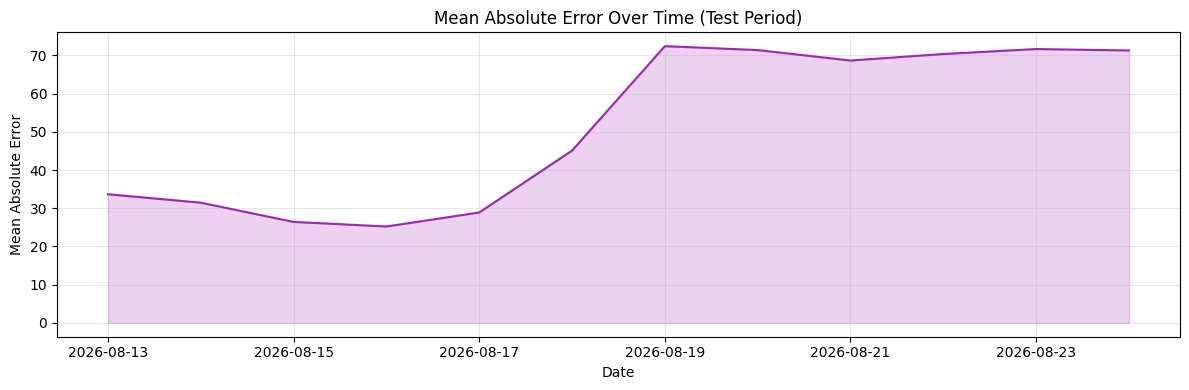

In [33]:
# Error over time
daily_err = demand_preds.groupby('date')['abs_error'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_err.index, daily_err.values, color='#9C27B0', linewidth=1.5)
ax.fill_between(daily_err.index, daily_err.values, alpha=0.2, color='#9C27B0')
ax.set_title('Mean Absolute Error Over Time (Test Period)')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Absolute Error')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


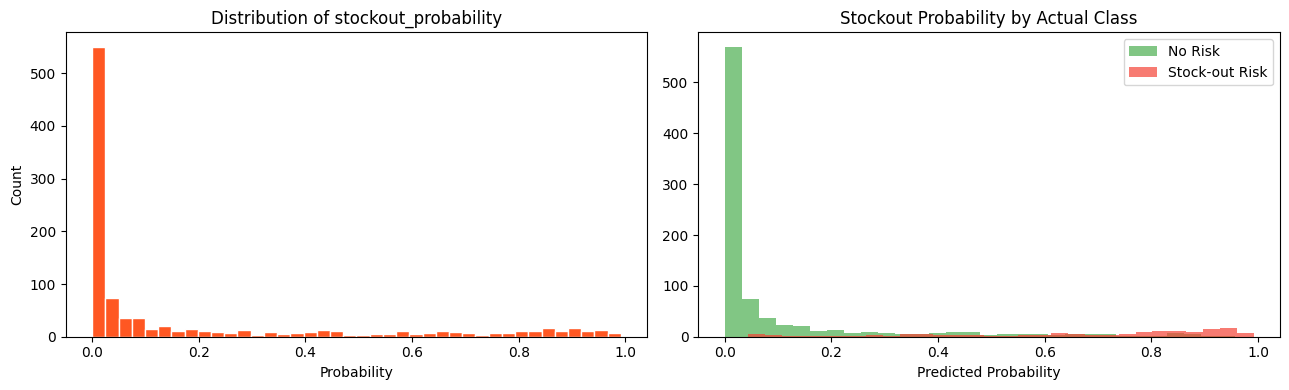

In [34]:
# Stockout probability distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(spred['stockout_probability'], bins=40, color='#FF5722', edgecolor='white')
axes[0].set_title('Distribution of stockout_probability')
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Count')

# Predicted probability for actual positives vs negatives
axes[1].hist(spred[spred['actual_stockout_flag']==0]['stockout_probability'],
             bins=30, alpha=0.7, label='No Risk', color='#4CAF50')
axes[1].hist(spred[spred['actual_stockout_flag']==1]['stockout_probability'],
             bins=30, alpha=0.7, label='Stock-out Risk', color='#F44336')
axes[1].set_title('Stockout Probability by Actual Class')
axes[1].set_xlabel('Predicted Probability')
axes[1].legend()

plt.tight_layout()
plt.show()


## 19. Final ML Conclusions

### Demand Model
| | Validation | Test |
|---|---|---|
| Baseline (rolling mean ×7) | MAE=30.71 | MAE=55.50 |
| **Random Forest (SELECTED)** | **MAE=26.03** | **MAE=51.87** |
| XGBoost | MAE=26.13 | MAE=51.92 |
| Linear Regression | MAE=29.05 | MAE=79.93 |

- **RandomForest** beats the baseline by ~15% on validation MAE.
- The dominant feature is `rolling_mean_14` (88.7% of importance).
- R² = 0.947 on test — model explains 94.7% of demand variance.

### Stockout Model
| | Val F1 | Test F1 | Test AUC |
|---|---|---|---|
| Logistic Regression | 0.596 | 0.514 | 0.862 |
| Decision Tree | 0.603 | 0.520 | 0.815 |
| Random Forest | 0.620 | 0.566 | 0.905 |
| **XGBoost (SELECTED)** | **0.811** | **0.698** | **0.950** |

- **XGBoost** dominates on all metrics.
- Recall = 72.8% on test — captures 73% of true stock-out cases.
- 44 false negatives (missed stock-outs) out of 162 positives.

### Key Limitations
1. Only 123 days of history — no annual seasonality captured.
2. P999 has only 11 days of data (cold-start product) — degraded accuracy.
3. Demand model has positive bias (mean error = +37.6 units) → slight under-prediction.

### Handoff to Person 3
- `models/demand_model.pkl` + `demand_scaler.pkl` → demand forecasting
- `models/stockout_model.pkl` + `stockout_scaler.pkl` → stockout risk scoring
- `data/processed/demand_predictions.csv` → demand forecast output
- `data/processed/stockout_predictions.csv` → stockout risk with probabilities
- Threshold tuning: adjust classification threshold on `stockout_probability` to tune Precision/Recall tradeoff.

**PERSON 3 CAN NOW START.**
